[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter13_lecture_notebook.ipynb)

# Chapter 13: Machine Learning in Finance — Lecture Notebook

**Modelling Financial Markets (MFM)** · Bucharest University of Economic Studies · Daniel Traian Pele

This notebook reproduces, step by step, the main empirical results of the Chapter 13 lecture on real data
(S&P 500 and VIX, 2000–2026), in the twelve sections listed below; the case study on the stochastic discount factor,
the inference appendix and the AI-for-discovery mini-case are computed in their own Quantlets (linked on the slides):

1. Signal-to-noise: what is (not) predictable in financial returns
2. Features and target without look-ahead
3. The bias–variance trade-off (decision trees vs random forests)
4. LASSO regularisation
5. Fractional differentiation (FFD): why an ADF rejection is not stationarity; local Whittle memory estimates
6. Triple-barrier labelling
7. Purged K-Fold cross-validation and the leakage experiment
8. Model comparison under purged CV
9. Feature importance: MDI, MDA, SHAP
10. Walk-forward backtest with transaction costs
11. The False Strategy Theorem
12. The Deflated Sharpe Ratio

Runtime: about 3–5 minutes on Colab.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_13'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/notebooks/EN


## 0. Setup

In [2]:
import sys
if 'google.colab' in sys.modules:
    !pip -q install shap

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# MFM colour palette
MainBlue, IDAred, Forest, Amber = '#1A3A6E', '#CD0000', '#2E7D32', '#B5853F'
Orange, Purple, Gray, LightGray = '#E67E22', '#8E44AD', '#1F2A44', '#C5D2E8'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False,
                     'font.size': 9, 'axes.titlesize': 10, 'legend.frameon': False,
                     'figure.dpi': 110, 'figure.facecolor': 'none', 'axes.facecolor': 'none',
                     'savefig.facecolor': 'none', 'savefig.transparent': True})
SEED = 42


def legend_bottom(ax, ncol=2, y=-0.25, handles=None, labels=None, **kw):
    """Legend outside the axes, bottom centre (MFM chart style)."""
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)

In [4]:
import os
DATA_URL = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
SERIES = {'sp500': 'GSPC.INDX', 'vix': 'VIX.INDX', 'btc': 'BTC-USD.CC', 'eth': 'ETH-USD.CC'}
START = {'sp500': '2000-01-01', 'vix': '2000-01-01', 'btc': '2014-09-17', 'eth': '2015-08-07'}


def load_data(name='sp500', start=None, end='2026-09-18'):
    """Daily OHLCV prices of the course data."""
    fname = SERIES[name] + '.csv'
    local = [os.path.join(d, 'data', 'market', fname) for d in ('.', '..', '../..', '../../..')]
    path = next((p for p in local if os.path.exists(p)), DATA_URL + fname)
    df = pd.read_csv(path, parse_dates=['date']).set_index('date')
    df = df.rename(columns=str.capitalize)[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df.loc[start or START[name]:end]


spx = load_data('sp500')['Close']
vix = load_data('vix')['Close']
log_spx = np.log(spx)
print('S&P 500:', spx.index[0].date(), '->', spx.index[-1].date(), len(spx), 'obs')

S&P 500: 2000-01-03 -> 2026-09-18 6718 obs


## 1. Signal-to-noise

Daily returns $r_t$ are almost uncorrelated, while absolute returns $|r_t|$ are strongly and persistently
autocorrelated (volatility clustering). **Direction is nearly unpredictable, risk is predictable.**
This is why out-of-sample $R^2$ for return prediction is typically well below 1% even with the best
machine-learning models (Gu, Kelly & Xiu, 2020), and why any "90% accuracy" claim on daily direction
should immediately raise suspicion of leakage or overfitting.

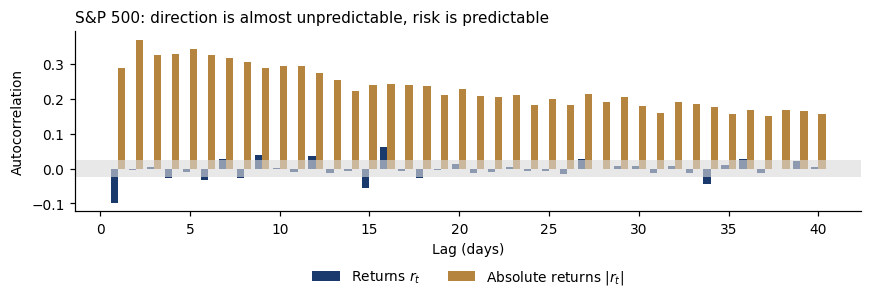

             lb_stat  lb_pvalue
r_t   5      71.2115        0.0
      20    162.0015        0.0
|r_t| 5    3695.8552        0.0
      20  10893.8332        0.0


In [5]:
r = log_spx.diff().dropna()
lags = np.arange(1, 41)
ac_r = [r.autocorr(l) for l in lags]
ac_a = [r.abs().autocorr(l) for l in lags]
band = 1.96 / np.sqrt(len(r))                     # 95% band under i.i.d.

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(lags - 0.2, ac_r, 0.4, color=MainBlue, label='Returns $r_t$')
ax.bar(lags + 0.2, ac_a, 0.4, color=Amber, label='Absolute returns $|r_t|$')
ax.axhspan(-band, band, color=LightGray, alpha=0.6, lw=0)
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Autocorrelation')
ax.set_title('S&P 500: direction is almost unpredictable, risk is predictable', loc='left')
legend_bottom(ax, ncol=2)
plt.tight_layout(); plt.show()

lb = pd.concat({'r_t': acorr_ljungbox(r, lags=[5, 20]), '|r_t|': acorr_ljungbox(r.abs(), lags=[5, 20])})
print(lb.round(4))

## 2. Features and target

We predict the **5-day direction** $y_t = \mathbb{1}\{\log P_{t+5} - \log P_t > 0\}$ from technical
features computed with information up to $t$ only: momentum over 1–120 days, realised volatility,
distance to moving averages, RSI and the VIX.

For every observation we also store $t_1$, the date when its label becomes known ($t+5$ trading days).
Because consecutive labels overlap in time, the observations are **not i.i.d.** — this matters for
cross-validation (Section 7).

In [6]:
def ffd_weights(d, threshold=1e-4, max_size=10_000):
    """w_k = -w_{k-1} (d - k + 1) / k, truncated when |w_k| < threshold."""
    w = [1.0]
    for k in range(1, max_size):
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
    return np.array(w)


def frac_diff_ffd(series, d, threshold=1e-4):
    """Fixed-width window fractional differentiation: X~_t = sum_k w_k X_{t-k}."""
    w = ffd_weights(d, threshold)
    x = series.dropna().values
    out = np.convolve(x, w, mode='valid')
    return pd.Series(out, index=series.dropna().index[len(w) - 1:])


def local_whittle(x, m=None, alpha=0.65):
    """Local Whittle estimate of the memory d (Robinson, 1995); returns (d_hat, SE = 1/(2 sqrt(m)))."""
    from scipy.optimize import minimize_scalar
    x = np.asarray(x, float); n = len(x); m = m or int(n ** alpha)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    I = np.abs(np.fft.fft(x - x.mean())[1:m + 1]) ** 2 / (2 * np.pi * n)
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    return minimize_scalar(R, bounds=(-0.49, 1.99), method='bounded').x, 1 / (2 * np.sqrt(m))


def exact_local_whittle(x, m=None, alpha=0.65):
    """Exact local Whittle (Shimotsu & Phillips, 2005), valid also for d >= 0.5; initial value removed (Shimotsu, 2010)."""
    from scipy.optimize import minimize_scalar
    x = np.asarray(x, float); x = x - x[0]; n = len(x); m = m or int(n ** alpha)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    k = np.arange(1, n); L = 2 ** int(np.ceil(np.log2(2 * n)))
    def R(d):
        pi = np.concatenate([[1.0], np.cumprod((k - 1 - d) / k)])
        u = np.fft.irfft(np.fft.rfft(x, L) * np.fft.rfft(pi, L), L)[:n]        # (1-B)^d x_t
        I = np.abs(np.fft.fft(u)[1:m + 1]) ** 2 / (2 * np.pi * n)
        return np.log(np.mean(I)) - 2 * d * np.mean(np.log(lam))
    return minimize_scalar(R, bounds=(-0.49, 1.99), method='bounded').x, 1 / (2 * np.sqrt(m))


def rsi(close, n=14):
    delta = close.diff()
    up = delta.clip(lower=0).ewm(alpha=1 / n).mean()
    dn = (-delta.clip(upper=0)).ewm(alpha=1 / n).mean()
    return 100 - 100 / (1 + up / dn)


def build_features(close, vix=None, d_ffd=None, periods=252):
    """Features that only use information available at time t (no look-ahead); periods = trading days per year (252 equities, 365 crypto)."""
    lp = np.log(close)
    r = lp.diff()
    f = pd.DataFrame(index=close.index)
    for h in (1, 5, 20, 60, 120):
        f[f'mom_{h}'] = lp.diff(h)                                     # momentum over h days
    f['vol_20'] = r.rolling(20).std() * np.sqrt(periods)
    f['vol_60'] = r.rolling(60).std() * np.sqrt(periods)
    f['vol_ratio'] = f['vol_20'] / f['vol_60']
    f['dist_ma50'] = lp - lp.rolling(50).mean()
    f['dist_ma200'] = lp - lp.rolling(200).mean()
    f['rsi_14'] = rsi(close) / 100
    if vix is not None:
        v = np.log(vix.reindex(close.index).ffill())
        f['vix_level'] = v
        f['vix_chg_5'] = v.diff(5)
    if d_ffd is not None:
        f['ffd_price'] = frac_diff_ffd(lp, d_ffd)
    return f


def sharpe_ratio(returns, periods=252):
    """Annualised Sharpe ratio (zero risk-free rate)."""
    r = np.asarray(returns)
    return np.sqrt(periods) * r.mean() / r.std(ddof=1)


H = 5                                              # label horizon (days)
feats = build_features(spx, vix=vix)
FEATS = list(feats.columns)
fwd = log_spx.shift(-H) - log_spx
df = feats.assign(fwd=fwd).dropna().loc['2001-01-01':]
df['y'] = (df['fwd'] > 0).astype(int)
pos = np.searchsorted(spx.index, df.index)
df['t1'] = spx.index[np.minimum(pos + H, len(spx) - 1)]   # when the label is known
print(df.shape, '| share of "up" labels:', round(df['y'].mean(), 3))
df[FEATS].describe().T.round(3)

(6461, 16) | share of "up" labels: 0.577


,count,mean,std,min,25%,50%,75%,max
mom_1,6461.0,0.000,0.012,-0.128,-0.005,0.001,0.006,0.110
mom_5,6461.0,0.001,0.025,-0.203,-0.010,0.003,0.014,0.175
mom_20,6461.0,0.005,0.047,-0.370,-0.015,0.012,0.032,0.211
mom_60,6461.0,0.016,0.077,-0.533,-0.017,0.030,0.063,0.330
mom_120,6461.0,0.031,0.112,-0.605,-0.018,0.051,0.097,0.421
vol_20,6461.0,0.161,0.106,0.033,0.097,0.134,0.191,0.979
vol_60,6461.0,0.166,0.096,0.050,0.109,0.135,0.198,0.740
vol_ratio,6461.0,0.972,0.245,0.322,0.797,0.969,1.136,1.696
dist_ma50,6461.0,0.007,0.041,-0.317,-0.010,0.015,0.032,0.137
dist_ma200,6461.0,0.025,0.084,-0.495,-0.008,0.045,0.078,0.193


## 3. Bias–variance trade-off

Accuracy is measured out of sample with purged 5-fold cross-validation (1% embargo): training observations whose
label window overlaps the test fold are dropped, as in Section 7, where the procedure is explained in detail. As the depth of a single decision tree grows, training
accuracy explodes while test accuracy does not improve: the extra complexity only fits noise.
Averaging many decorrelated trees (random forest) reduces the variance but cannot create signal that is
not there. The dashed line is the naive benchmark "always predict up".

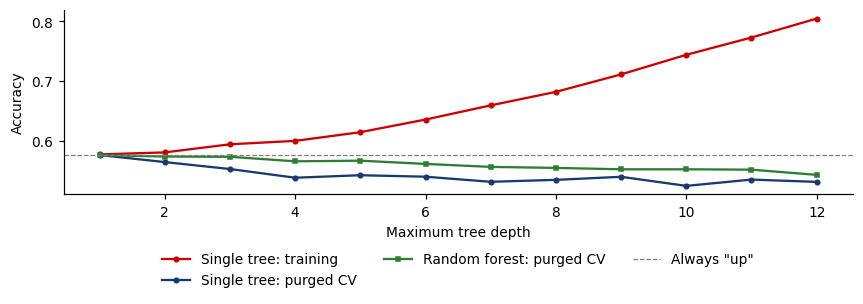

,tree_train,tree_cv,rf_cv
depth,,,
1,0.578,0.577,0.576
2,0.581,0.565,0.574
3,0.594,0.553,0.574
4,0.600,0.539,0.566
5,0.615,0.543,0.567
6,0.636,0.540,0.562
7,0.660,0.532,0.557
8,0.682,0.535,0.555
9,0.711,0.540,0.553


In [7]:
class PurgedKFold:
    """K-Fold without shuffling for overlapping labels.

    t1: pd.Series indexed by observation time t0, value = time t1 when the label is known.
    Purging: drop training observations whose [t0, t1] overlaps the test period.
    Embargo: also drop a fraction pct_embargo of observations right after the test set.
    """

    def __init__(self, n_splits=5, t1=None, pct_embargo=0.01):
        self.n_splits, self.t1, self.pct_embargo = n_splits, t1, pct_embargo

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        idx = np.arange(len(X))
        t0, t1 = self.t1.index.values, self.t1.values
        embargo = int(len(X) * self.pct_embargo)
        for test in np.array_split(idx, self.n_splits):
            start, stop = test[0], test[-1]
            test_t0, test_t1 = t0[start], t1[test].max()
            before = idx[t1 < test_t0]                                  # labels known before the test starts
            after_start = min(stop + 1 + embargo, len(X))               # embargo
            after = idx[after_start:][t0[after_start:] > test_t1]       # start after the last test label
            yield np.concatenate([before, after]), test


Xa, ya = df[FEATS].values, df['y'].values
cv3 = PurgedKFold(5, t1=df['t1'], pct_embargo=0.01)           # purged 5-fold CV, 1% embargo (Section 7)
rows = []
for depth in range(1, 13):
    a_tr, a_te, a_rf = [], [], []
    for tr, te in cv3.split(Xa):
        tree = DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(Xa[tr], ya[tr])
        rf = RandomForestClassifier(n_estimators=100, max_depth=depth, max_features='sqrt',
                                    n_jobs=-1, random_state=SEED).fit(Xa[tr], ya[tr])
        a_tr.append(accuracy_score(ya[tr], tree.predict(Xa[tr])))
        a_te.append(accuracy_score(ya[te], tree.predict(Xa[te])))
        a_rf.append(accuracy_score(ya[te], rf.predict(Xa[te])))
    rows.append((depth, np.mean(a_tr), np.mean(a_te), np.mean(a_rf)))
bv = pd.DataFrame(rows, columns=['depth', 'tree_train', 'tree_cv', 'rf_cv']).set_index('depth')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(bv.index, bv['tree_train'], 'o-', color=IDAred, ms=3, label='Single tree: training')
ax.plot(bv.index, bv['tree_cv'], 'o-', color=MainBlue, ms=3, label='Single tree: purged CV')
ax.plot(bv.index, bv['rf_cv'], 's-', color=Forest, ms=3, label='Random forest: purged CV')
ax.axhline(ya.mean(), color=Gray, ls='--', lw=0.8, label='Always "up"')
ax.set_xlabel('Maximum tree depth'); ax.set_ylabel('Accuracy'); legend_bottom(ax, ncol=3)
plt.tight_layout(); plt.show()
bv.round(3)

## 4. LASSO regularisation

The $L_1$-penalised logistic regression of scikit-learn (`liblinear`) solves
$$\min_{\beta_0,\boldsymbol\beta}\; -\sum_{t}\Big[y_t\log p_t + (1-y_t)\log(1-p_t)\Big] + \lambda\,\big(\|\boldsymbol\beta\|_1 + |\beta_0|\big),
\qquad \lambda = 1/C,\qquad p_t = \frac{1}{1+e^{-(\beta_0 + \mathbf x_t^\top\boldsymbol\beta)}},$$
with the loss **summed** over observations (for the mean loss the penalty is $1/(nC)$); `liblinear` also penalises the intercept.
The $L_1$ penalty sets coefficients **exactly to zero**, performing variable selection. Features are
standardised on the training set only. We train on 2001–2017 and test on 2018–2026; training observations whose
label window reaches into the test period are dropped (purge of the boundary). The path below shows the coefficients as $\lambda$ decreases;
the right panel shows the test AUC for each $\lambda$.

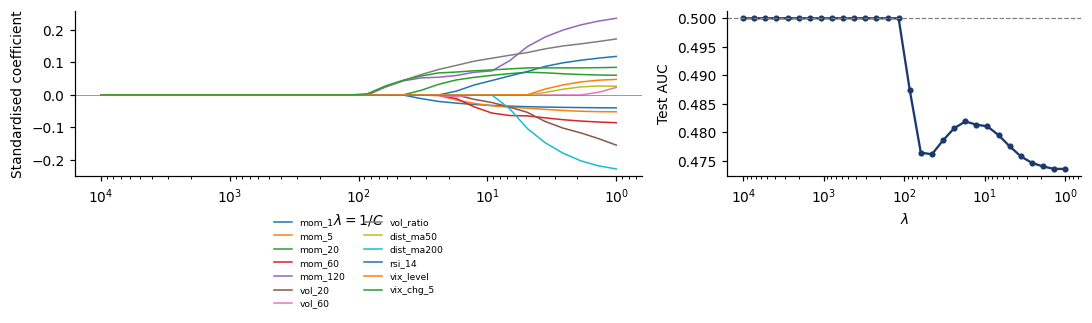

best non-empty model: C = 0.01172, test AUC = 0.487, features = ['vol_ratio', 'vix_chg_5']
Does any penalty beat the constant model (AUC = 0.5) clearly? Look at the table.


,C,n_nonzero,test_AUC
0,0.0001,0,0.5000
3,0.0003,0,0.5000
6,0.0007,0,0.5000
9,0.0017,0,0.5000
12,0.0045,0,0.5000
15,0.0117,2,0.4875
18,0.0304,5,0.4786
21,0.0788,9,0.4814
24,0.2043,11,0.4776
27,0.5298,12,0.4740


In [8]:
train_mask = df.index < '2018-01-01'
test_start = df.index[~train_mask][0]
train_idx = df.index[train_mask & (df['t1'] < test_start)]      # purge the train/test boundary
test_idx = df.index[~train_mask]
Xtr, ytr = df.loc[train_idx, FEATS], df.loc[train_idx, 'y']
Xte, yte = df.loc[test_idx, FEATS], df.loc[test_idx, 'y']

scaler = StandardScaler().fit(Xtr)                   # fit on training data only
Ztr, Zte = scaler.transform(Xtr), scaler.transform(Xte)
Cs = np.logspace(-4, 0, 30)
coefs, aucs = [], []
for C in Cs:
    m = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=5000, random_state=SEED).fit(Ztr, ytr)
    coefs.append(m.coef_.ravel())
    aucs.append(roc_auc_score(yte, m.predict_proba(Zte)[:, 1]) if np.any(m.coef_) else 0.5)
coefs = np.array(coefs)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={'width_ratios': [1.6, 1]})
for i, name in enumerate(FEATS):
    axes[0].plot(1 / Cs, coefs[:, i], lw=1, label=name)
axes[0].set_xscale('log'); axes[0].invert_xaxis(); axes[0].axhline(0, color=Gray, lw=0.5)
axes[0].set_xlabel(r'$\lambda = 1/C$'); axes[0].set_ylabel('Standardised coefficient')
legend_bottom(axes[0], ncol=2, y=-0.2, fontsize=6)
axes[1].plot(1 / Cs, aucs, 'o-', ms=3, color=MainBlue); axes[1].axhline(0.5, color=Gray, ls='--', lw=0.8)
axes[1].set_xscale('log'); axes[1].invert_xaxis(); axes[1].set_xlabel(r'$\lambda$'); axes[1].set_ylabel('Test AUC')
plt.tight_layout(); plt.show()

nz = (coefs != 0).sum(1)
lasso = pd.DataFrame({'C': Cs, 'n_nonzero': nz, 'test_AUC': aucs})
best = int(np.argmax(np.where(nz > 0, aucs, -np.inf)))
print(f'best non-empty model: C = {Cs[best]:.4g}, test AUC = {aucs[best]:.3f}, '
      f'features = {[f for f, c in zip(FEATS, coefs[best]) if c != 0]}')
print('Does any penalty beat the constant model (AUC = 0.5) clearly? Look at the table.')
lasso.iloc[::3].round(4)

## 5. Fractional differentiation

Prices are non-stationary ($d=0$); returns ($d=1$) are stationary but have erased the memory of the level.
Fractional differentiation applies $(1-B)^d$ with a real $d\in(0,1)$:
$$\tilde X_t = \sum_{k=0}^{\infty} w_k X_{t-k},\qquad w_0 = 1,\quad w_k = -w_{k-1}\,\frac{d-k+1}{k}.$$
With a fixed-width window (FFD) the weights are truncated when $|w_k|<\tau$ ($\tau=10^{-4}$).
The heuristic of López de Prado (2018) looks for the **smallest $d^*$** for which the ADF test rejects a unit root at 5%.
Two warnings, checked below: (i) the truncated weights do not sum to zero, so the FFD series of an $I(1)$ price is
$\big(\sum_{k\le K} w_k\big)\log P_t$ plus a stationary part, i.e. **still $I(1)$**; (ii) the ADF with one lag over-rejects
on such a series. The memory is therefore estimated directly with the (exact) local Whittle estimator and its CI. For the FFD
series this estimate (about $1-d$) is the *apparent* memory over the frequency band: above frequency $1/K$ the filter acts as $(1-B)^d$,
and only about $n/(2\pi K) \approx 2$ of the $m$ frequencies lie below $1/K$, where the unit root returns; the integration order is still 1.

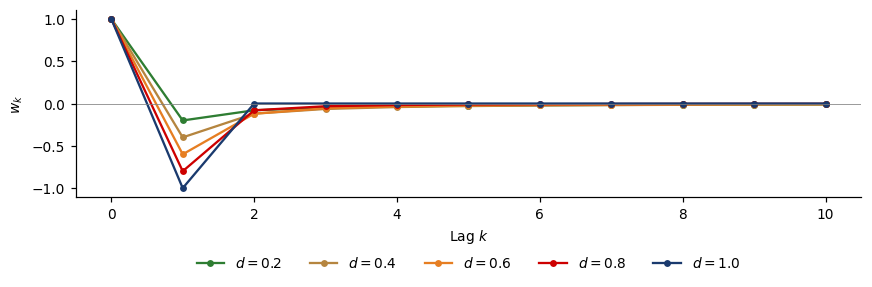

d* = 0.25 | correlation with log price = 0.984


d,0.00,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,...,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00
adf,0.840,0.165,-0.528,-1.243,-1.986,-2.964,-4.124,-5.584,-7.499,-9.830,...,-16.185,-20.223,-24.876,-30.035,-35.419,-41.092,-46.546,-51.976,-56.866,-61.619
crit_5%,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,...,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862
corr,1.000,1.000,0.998,0.996,0.991,0.984,0.975,0.961,0.941,0.915,...,0.827,0.763,0.684,0.595,0.502,0.407,0.319,0.233,0.154,0.028


In [9]:
fig, ax = plt.subplots(figsize=(8, 2.8))
for d, c in zip([0.2, 0.4, 0.6, 0.8, 1.0], [Forest, Amber, Orange, IDAred, MainBlue]):
    w = ffd_weights(d, threshold=0, max_size=11)
    ax.plot(range(len(w)), w, marker='o', ms=3.5, color=c, label=f'$d={d}$')
ax.axhline(0, color=Gray, lw=0.5); ax.set_xlabel('Lag $k$'); ax.set_ylabel('$w_k$'); legend_bottom(ax, ncol=5)
plt.tight_layout(); plt.show()


def find_min_d(logp, grid=np.round(np.arange(0, 1.01, 0.05), 2)):
    """Smallest d at which the ADF (constant, 1 lag) rejects on the FFD series (López de Prado's heuristic)."""
    rows = []
    for d in grid:
        x = frac_diff_ffd(logp, d).dropna()
        adf = adfuller(x, maxlag=1, regression='c', autolag=None)
        rows.append((d, adf[0], adf[4]['5%'], np.corrcoef(logp.loc[x.index], x)[0, 1]))
    out = pd.DataFrame(rows, columns=['d', 'adf', 'crit_5%', 'corr']).set_index('d')
    return out, out.index[out['adf'] < out['crit_5%']].min()


ffd_table, d_star = find_min_d(log_spx)
print('d* =', d_star, '| correlation with log price =', round(ffd_table.loc[d_star, 'corr'], 3))
ffd_table.round(3).T

In [10]:
# (i) the truncated weights do not sum to zero; (ii) ADF with more lags; (iii) memory estimated directly
w = ffd_weights(d_star)
print(f'K = {len(w) - 1} lags, sum of weights = {w.sum():.3f}')
x_ffd = frac_diff_ffd(log_spx, d_star)
a1, aic = adfuller(x_ffd, maxlag=1, regression='c', autolag=None), adfuller(x_ffd, regression='c', autolag='AIC')
print(f'ADF (1 lag) = {a1[0]:.2f}; ADF (AIC, {aic[2]} lags) = {aic[0]:.2f}, p = {aic[1]:.2f}')
r_spx = log_spx.diff().dropna()
for lab, v, est in (('log price (ELW)', log_spx.values, exact_local_whittle), (f'FFD d={d_star} (ELW)', x_ffd.values, exact_local_whittle),
                    ('returns (LW)', r_spx.values, local_whittle), ('|returns| (LW)', r_spx.abs().values, local_whittle)):
    dh, se = est(v)
    print(f'{lab:18s} d_hat = {dh:.3f}, 95% CI [{dh - 1.96 * se:.3f}; {dh + 1.96 * se:.3f}]')

K = 444 lags, sum of weights = 0.178


ADF (1 lag) = -2.96; ADF (AIC, 34 lags) = -0.72, p = 0.84
log price (ELW)    d_hat = 0.994, 95% CI [0.938; 1.050]
FFD d=0.25 (ELW)   d_hat = 0.749, 95% CI [0.691; 0.806]
returns (LW)       d_hat = -0.013, 95% CI [-0.069; 0.043]
|returns| (LW)     d_hat = 0.530, 95% CI [0.475; 0.586]


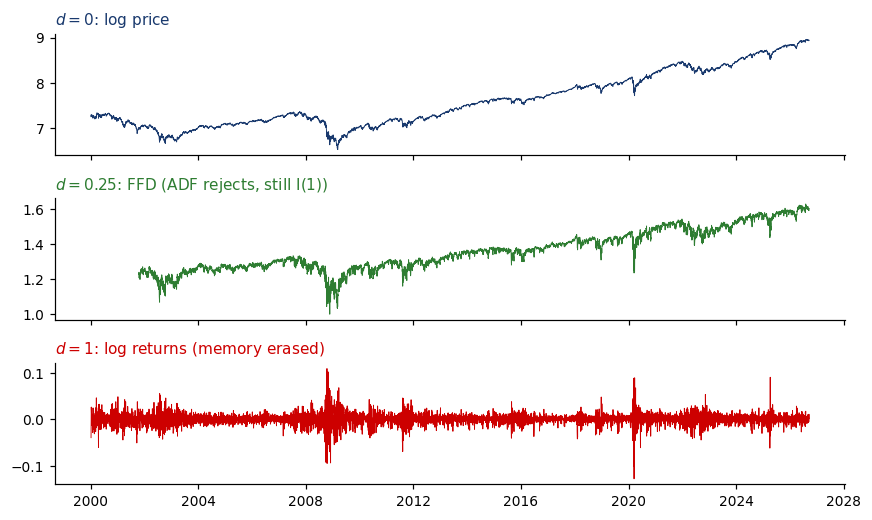

(6269, 17)


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 4.8), sharex=True)
panels = [(log_spx, MainBlue, '$d=0$: log price'),
          (frac_diff_ffd(log_spx, d_star), Forest, f'$d={d_star}$: FFD (ADF rejects, still I(1))'),
          (log_spx.diff(), IDAred, '$d=1$: log returns (memory erased)')]
for ax, (s, c, t) in zip(axes, panels):
    ax.plot(s.index, s.values, color=c, lw=0.6); ax.set_title(t, loc='left', color=c)
plt.tight_layout(); plt.show()

# add the FFD price as an extra feature (a scaled price level, as in the lecture)
df['ffd_price'] = frac_diff_ffd(log_spx, d_star).reindex(df.index)
df = df.dropna()
FEATS = FEATS + ['ffd_price']
print(df.shape)

## 6. Triple-barrier labelling

Fixed-horizon labels ignore the path and the volatility regime. The **triple-barrier method**
(López de Prado, 2018) opens, at each event $t_0$, three barriers:

* upper (profit-taking): $\log P_t - \log P_{t_0} \ge \text{pt}\cdot\sigma_{t_0}\sqrt h$ → label $+1$
* lower (stop-loss): $\log P_t - \log P_{t_0} \le -\text{sl}\cdot\sigma_{t_0}\sqrt h$ → label $-1$
* vertical (time limit) at $t_0 + h$ → label = sign of the return (or "time-out")

where $\sigma_{t_0}$ is an EWMA estimate of daily volatility. The first barrier touched defines the label and $t_1$.

Label shares (signed labels; vertical exits take the sign of the return):
    Fixed horizon (10d)  Triple barrier
+1                0.605           0.591
-1                0.395           0.409

Triple barrier: exit types:
barrier
upper       0.196
lower       0.213
vertical    0.590
Name: proportion, dtype: float64


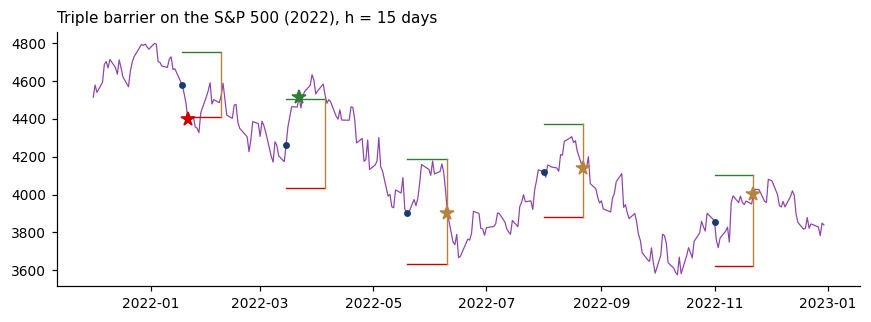

In [12]:
def get_daily_vol(close, span=50):
    """EWMA volatility: square root of the EWMA of squared deviations of daily log returns."""
    return np.log(close).diff().ewm(span=span).std()


def triple_barrier(close, events_idx, vol, pt=1.0, sl=1.0, horizon=10):
    """Triple-barrier labels: +1 upper, -1 lower, sign of the return at the vertical barrier."""
    logp = np.log(close)
    pos = {t: i for i, t in enumerate(close.index)}
    rows = []
    for t0 in events_idx:
        i0 = pos[t0]
        if i0 + horizon >= len(close) or np.isnan(vol.iloc[i0]):
            continue                                   # incomplete h-day window at the end of the sample: censored, skipped
        i1 = i0 + horizon
        width = vol.iloc[i0] * np.sqrt(horizon)
        path = logp.iloc[i0 + 1:i1 + 1] - logp.iloc[i0]
        up = path[path >= pt * width].index.min() if pt > 0 else pd.NaT
        dn = path[path <= -sl * width].index.min() if sl > 0 else pd.NaT
        first = min([t for t in (up, dn) if pd.notna(t)], default=pd.NaT)
        if pd.isna(first):
            t1, barrier = close.index[i1], 'vertical'
            label = int(np.sign(path.iloc[-1])) if len(path) else 0
        else:
            t1 = first
            barrier = 'upper' if first == up else 'lower'
            label = 1 if barrier == 'upper' else -1
        rows.append((t0, t1, logp.loc[t1] - logp.iloc[i0], label, barrier, width))
    return pd.DataFrame(rows, columns=['t0', 't1', 'ret', 'label', 'barrier', 'width']).set_index('t0')


vol = get_daily_vol(spx)
events = spx.index[250:-20]
tb = triple_barrier(spx, events, vol, pt=1.0, sl=1.0, horizon=10)
fixed = np.sign(log_spx.shift(-10) - log_spx).reindex(tb.index)
labels = pd.DataFrame({'Fixed horizon (10d)': [np.mean(fixed > 0), np.mean(fixed < 0)],
                       'Triple barrier': [np.mean(tb['label'] > 0), np.mean(tb['label'] < 0)]},
                      index=['+1', '-1'])
exits = tb['barrier'].value_counts(normalize=True).reindex(['upper', 'lower', 'vertical'])
print('Label shares (signed labels; vertical exits take the sign of the return):')
print(labels.round(3))
print('\nTriple barrier: exit types:')
print(exits.round(3))

# illustration on 2022
close = spx.loc['2021-12-01':'2022-12-31']
ev = [close.index[close.index.searchsorted(t)] for t in ['2022-01-18', '2022-03-15', '2022-05-19', '2022-08-01', '2022-11-01']]
tb_ex = triple_barrier(close, ev, vol.reindex(close.index), pt=1.0, sl=1.0, horizon=15)
colors = {'upper': Forest, 'lower': IDAred, 'vertical': Amber}
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(close.index, close.values, color=Purple, lw=0.8)
for t0, row in tb_ex.iterrows():
    p0, i0 = close.loc[t0], close.index.get_loc(t0)
    tv = close.index[min(i0 + 15, len(close) - 1)]
    up, dn = p0 * np.exp(row['width']), p0 * np.exp(-row['width'])
    ax.plot([t0, tv], [up, up], color=Forest, lw=0.9); ax.plot([t0, tv], [dn, dn], color=IDAred, lw=0.9)
    ax.plot([tv, tv], [dn, up], color=Amber, lw=0.9); ax.plot(t0, p0, 'o', color=MainBlue, ms=3.5)
    ax.plot(row['t1'], close.loc[row['t1']], '*', ms=9, color=colors[row['barrier']])
ax.set_title('Triple barrier on the S&P 500 (2022), h = 15 days', loc='left')
plt.tight_layout(); plt.show()

## 7. Purged K-Fold and the leakage experiment

With overlapping labels, a training observation adjacent to the test set shares most of its label window
with test observations: standard (shuffled) K-Fold **leaks** information from the test set into training.
**Purging** removes training observations whose $[t_0, t_1]$ overlaps the test period, and an
**embargo** removes a small buffer after it.

*Experiment:* a pure random walk (nothing is predictable), labels = sign of the next 20-day move,
features = persistent noise (20-day rolling means of white noise). Shuffled K-Fold "finds" a signal;
purged K-Fold correctly reports a coin flip.

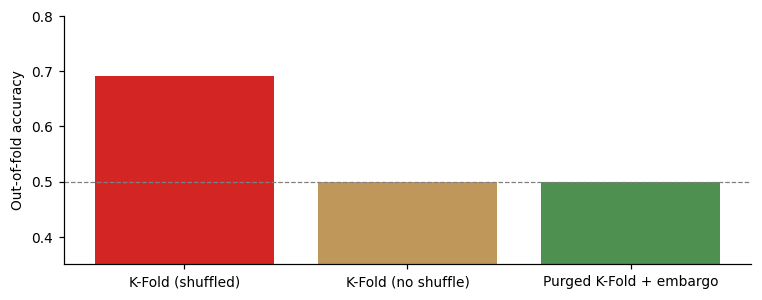

K-Fold (shuffled)          0.691
K-Fold (no shuffle)        0.500
Purged K-Fold + embargo    0.499
dtype: float64

In [13]:
rng = np.random.default_rng(SEED)
n, h = 3000, 20
p = pd.Series(np.cumsum(rng.normal(0, 0.01, n + h)))                  # pure random walk
y_leak = (p.shift(-h) - p > 0).astype(int).iloc[:n].values             # overlapping 20-day labels
X_leak = np.column_stack([pd.Series(rng.normal(size=n + h)).rolling(h).mean().bfill().iloc[:n] for _ in range(5)])
t1_leak = pd.Series(np.arange(n) + h, index=np.arange(n))

schemes = {'K-Fold (shuffled)': KFold(5, shuffle=True, random_state=SEED),
           'K-Fold (no shuffle)': KFold(5, shuffle=False),
           'Purged K-Fold + embargo': PurgedKFold(5, t1=t1_leak, pct_embargo=0.01)}
model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
leak = {}
for name, cv in schemes.items():
    leak[name] = np.mean([accuracy_score(y_leak[te], model.fit(X_leak[tr], y_leak[tr]).predict(X_leak[te]))
                          for tr, te in cv.split(X_leak)])

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(range(3), list(leak.values()), color=[IDAred, Amber, Forest], alpha=0.85)
ax.axhline(0.5, color=Gray, ls='--', lw=0.8)
ax.set_xticks(range(3), list(leak.keys())); ax.set_ylim(0.35, 0.8); ax.set_ylabel('Out-of-fold accuracy')
plt.tight_layout(); plt.show()
pd.Series(leak).round(3)

## 8. Model comparison under purged CV

Four model families, each evaluated with purged 5-fold CV (1% embargo) on the S&P 500 5-day direction.
The relevant benchmark is not 50% but the share of the majority class in each test fold ("always up").

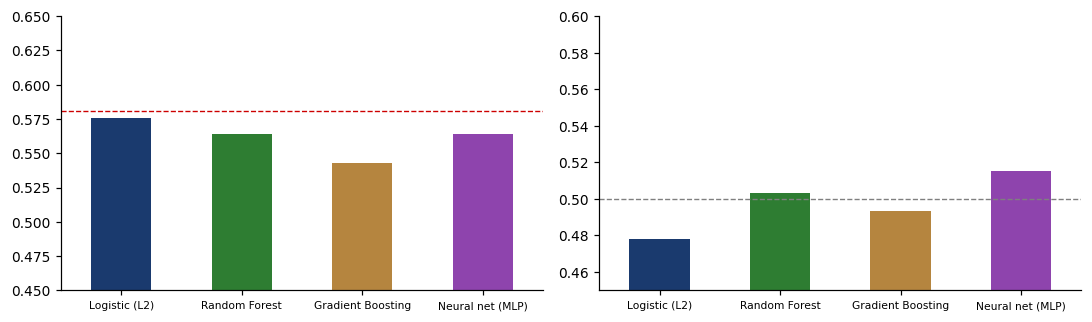

,accuracy,AUC,always_up
model,,,
Logistic (L2),0.576,0.478,0.581
Random Forest,0.564,0.504,0.581
Gradient Boosting,0.543,0.493,0.581
Neural net (MLP),0.564,0.515,0.581


In [14]:
models = {
    'Logistic (L2)': make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000)),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=100, max_features='sqrt',
                                            n_jobs=-1, random_state=SEED),
    'Gradient Boosting': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=200,
                                                        min_samples_leaf=100, random_state=SEED),
    'Neural net (MLP)': make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-2,
                                                                      early_stopping=True, max_iter=500,
                                                                      random_state=SEED)),
}
X, y = df[FEATS].values, df['y'].values
cv = PurgedKFold(5, t1=df['t1'], pct_embargo=0.01)
rows = []
for name, m in models.items():
    acc, auc, base = [], [], []
    for tr, te in cv.split(X):
        prob = m.fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        acc.append(accuracy_score(y[te], prob > 0.5)); auc.append(roc_auc_score(y[te], prob))
        base.append(max(y[te].mean(), 1 - y[te].mean()))
    rows.append((name, np.mean(acc), np.mean(auc), np.mean(base)))
comp = pd.DataFrame(rows, columns=['model', 'accuracy', 'AUC', 'always_up']).set_index('model')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
comp['accuracy'].plot.bar(ax=axes[0], color=[MainBlue, Forest, Amber, Purple], rot=0)
axes[0].axhline(comp['always_up'].mean(), color=IDAred, ls='--', lw=0.9); axes[0].set_ylim(0.45, 0.65)
comp['AUC'].plot.bar(ax=axes[1], color=[MainBlue, Forest, Amber, Purple], rot=0)
axes[1].axhline(0.5, color=Gray, ls='--', lw=0.9); axes[1].set_ylim(0.45, 0.6)
for ax in axes: ax.tick_params(axis='x', labelsize=7); ax.set_xlabel('')
plt.tight_layout(); plt.show()
comp.round(3)

## 9. Feature importance: MDI, MDA, SHAP

* **MDI** (mean decrease in impurity): computed in-sample from the trees; biased towards continuous,
  high-cardinality features and blind to overfitting.
* **MDA** (mean decrease in accuracy / permutation importance): out-of-sample drop in AUC when a feature
  is shuffled; negative values mean the feature *hurts* out of sample.
* **SHAP**: Shapley-value attributions of each prediction to the features (Lundberg & Lee, 2017).

Train on the first 70% of the sample; evaluate on the remaining 30% after a purge/embargo gap.

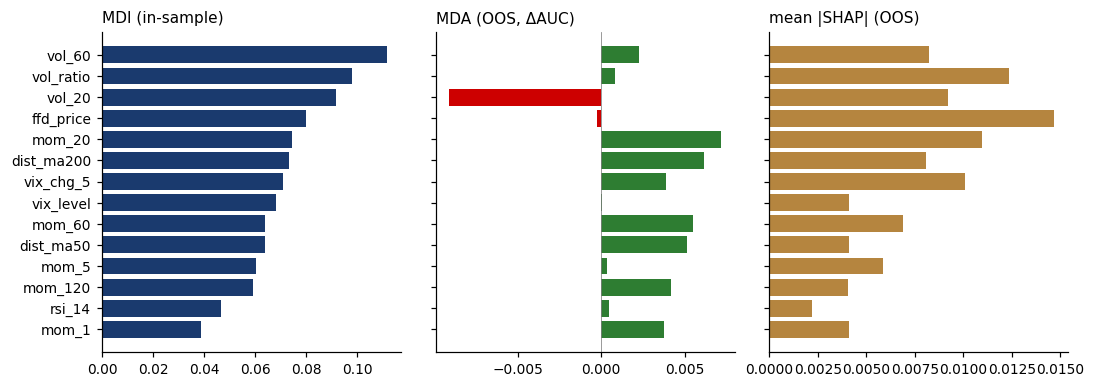

,MDI,MDA,SHAP
mom_20,0.0743,0.0072,0.0110
dist_ma200,0.0731,0.0061,0.0081
mom_60,0.0640,0.0055,0.0069
dist_ma50,0.0638,0.0051,0.0041
mom_120,0.0592,0.0042,0.0040
vix_chg_5,0.0708,0.0039,0.0101
mom_1,0.0389,0.0038,0.0041
vol_60,0.1115,0.0022,0.0082
vol_ratio,0.0980,0.0008,0.0124
rsi_14,0.0465,0.0005,0.0022


In [15]:
Xdf = df[FEATS]
split = int(len(df) * 0.7)
gap = split + H + int(0.01 * len(df))                     # purge + embargo
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=100, max_features='sqrt',
                            n_jobs=-1, random_state=SEED).fit(Xdf.iloc[:split], y[:split])
mdi = pd.Series(rf.feature_importances_, index=FEATS)
mda = pd.Series(permutation_importance(rf, Xdf.iloc[gap:], y[gap:], scoring='roc_auc', n_repeats=5,
                                       random_state=SEED, n_jobs=-1).importances_mean, index=FEATS)
try:
    import shap
    sample = Xdf.iloc[gap:].sample(300, random_state=SEED)
    sv = shap.TreeExplainer(rf).shap_values(sample)
    sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if np.ndim(sv) == 3 else sv)
    shap_imp = pd.Series(np.abs(sv).mean(0), index=FEATS)
except Exception as e:
    print('SHAP skipped:', e)
    shap_imp = pd.Series(np.nan, index=FEATS)

imp = pd.DataFrame({'MDI': mdi, 'MDA': mda, 'SHAP': shap_imp}).sort_values('MDI')
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey=True)
axes[0].barh(imp.index, imp['MDI'], color=MainBlue); axes[0].set_title('MDI (in-sample)', loc='left')
axes[1].barh(imp.index, imp['MDA'], color=np.where(imp['MDA'] > 0, Forest, IDAred))
axes[1].axvline(0, color=Gray, lw=0.5); axes[1].set_title('MDA (OOS, ΔAUC)', loc='left')
axes[2].barh(imp.index, imp['SHAP'], color=Amber); axes[2].set_title('mean |SHAP| (OOS)', loc='left')
plt.tight_layout(); plt.show()
imp.sort_values('MDA', ascending=False).round(4)

## 10. Walk-forward backtest with costs

Each year from 2010 onwards, a gradient-boosting model is re-trained on **all past data whose labels are
already known** ($t_1 <$ first day of the year) and then produces a long/cash signal for every day of
that year: hold the S&P 500 if $\hat p > 0.5$, otherwise stay in cash. Each change of position costs 5 bp.
Returns are daily log returns; the net return $w_t r_{t+1} - c\,|w_t - w_{t-1}|$ is the first-order approximation of $\log(e^{r} - c)$,
an error of order $c\,|r|$ per trade. The order $d$ of the FFD price feature was chosen on the full sample (Section 5): the second cell
repeats the backtest with $d$ chosen by the same rule on data up to 2009 only.

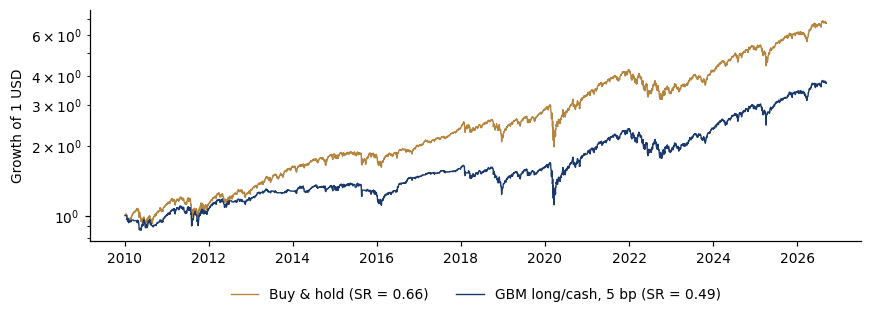

exposure = 79%, trades per year = 30.4


In [16]:
cost_bp = 5
ret1 = log_spx.diff().shift(-1).reindex(df.index)             # next-day return
signal = pd.Series(np.nan, index=df.index)
for yr in range(2010, df.index[-1].year + 1):
    test = df.index[df.index.year == yr]
    train = df.index[df['t1'] < test[0]]                        # purged training window
    m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=150,
                                       min_samples_leaf=100, random_state=SEED)
    m.fit(df.loc[train, FEATS], df.loc[train, 'y'])
    signal.loc[test] = (m.predict_proba(df.loc[test, FEATS])[:, 1] > 0.5).astype(float)
pos_ = signal.dropna()
turnover = pos_.diff().abs().fillna(pos_.iloc[0])
strat = (pos_ * ret1.loc[pos_.index] - turnover * cost_bp / 1e4).dropna()
bh = ret1.loc[strat.index]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(bh.index, np.exp(bh.cumsum()), color=Amber, lw=0.9, label=f'Buy & hold (SR = {sharpe_ratio(bh):.2f})')
ax.plot(strat.index, np.exp(strat.cumsum()), color=MainBlue, lw=0.9,
        label=f'GBM long/cash, {cost_bp} bp (SR = {sharpe_ratio(strat):.2f})')
ax.set_yscale('log'); ax.set_ylabel('Growth of 1 USD'); legend_bottom(ax, ncol=2, y=-0.15)
plt.tight_layout(); plt.show()
print(f'exposure = {pos_.mean():.0%}, trades per year = {turnover.sum() / (len(pos_) / 252):.1f}')

In [17]:
# no look-ahead in d: choose it by the same ADF rule on data up to 2009 and freeze it
_, d_2009 = find_min_d(log_spx.loc[:'2009-12-31'])
df_f = df.copy()
df_f['ffd_price'] = frac_diff_ffd(log_spx, d_2009).reindex(df_f.index)
df_f = df_f.dropna()
sig_f = pd.Series(np.nan, index=df_f.index)
for yr in range(2010, df_f.index[-1].year + 1):
    test = df_f.index[df_f.index.year == yr]
    train = df_f.index[df_f['t1'] < test[0]]
    m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=150,
                                       min_samples_leaf=100, random_state=SEED)
    m.fit(df_f.loc[train, FEATS], df_f.loc[train, 'y'])
    sig_f.loc[test] = (m.predict_proba(df_f.loc[test, FEATS])[:, 1] > 0.5).astype(float)
pf = sig_f.dropna()
strat_f = (pf * ret1.loc[pf.index] - pf.diff().abs().fillna(pf.iloc[0]) * cost_bp / 1e4).dropna()
print(f'd chosen on data up to 2009 = {d_2009}: SR = {sharpe_ratio(strat_f):.2f} '
      f'(full-sample d = {d_star}: {sharpe_ratio(strat):.2f}; buy & hold {sharpe_ratio(bh):.2f})')

d chosen on data up to 2009 = 0.15: SR = 0.47 (full-sample d = 0.25: 0.49; buy & hold 0.66)


## 11. The False Strategy Theorem

Try $N$ independent strategies with **zero** true Sharpe ratio. Their estimated Sharpe ratios are
approximately $\mathcal N(0, V[\widehat{SR}])$, and the expected **maximum** is
(Bailey & López de Prado, 2014)
$$E\big[\max_n \widehat{SR}_n\big] \approx \sqrt{V[\widehat{SR}]}\left((1-\gamma)\,\Phi^{-1}\!\Big(1-\frac1N\Big) + \gamma\,\Phi^{-1}\!\Big(1-\frac{1}{Ne}\Big)\right),$$
with $\gamma \approx 0.5772$ the Euler–Mascheroni constant. With 5 years of daily data,
$V[\widehat{SR}_{ann}] \approx 1/5$, so trying ~100 strategies produces an annualised Sharpe above 1 **by luck alone**.

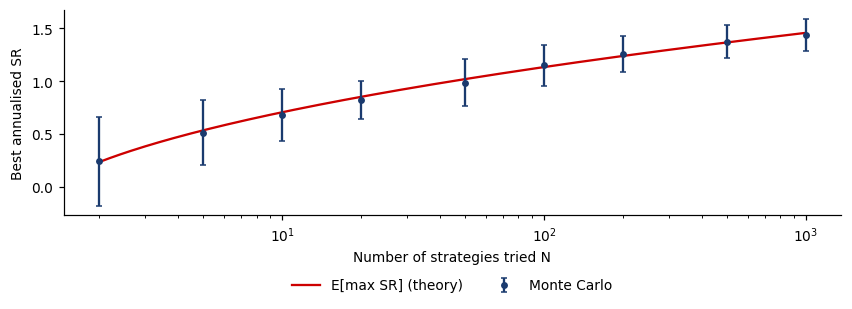

In [18]:
EULER_GAMMA = 0.5772156649015329


def probabilistic_sharpe_ratio(sr, sr_benchmark, T, skew=0.0, kurt=3.0):
    """PSR(SR*) = Phi((SR - SR*) sqrt(T-1) / sqrt(1 - g3 SR + (g4 - 1)/4 SR^2)); SR per period, kurt = raw kurtosis (Normal distribution = 3)."""
    denom = np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    return stats.norm.cdf((sr - sr_benchmark) * np.sqrt(T - 1) / denom)


def expected_max_sharpe(n_trials, sr_std=1.0):
    """False Strategy Theorem: E[max SR] ~ sqrt(V[SR]) ((1-g) Phi^-1(1-1/N) + g Phi^-1(1-1/(N e)))."""
    n = np.asarray(n_trials, dtype=float)
    return sr_std * ((1 - EULER_GAMMA) * stats.norm.ppf(1 - 1 / n)
                     + EULER_GAMMA * stats.norm.ppf(1 - 1 / (n * np.e)))


def deflated_sharpe_ratio(sr, T, n_trials, sr_std, skew=0.0, kurt=3.0):
    """DSR = PSR(SR_0), SR_0 = E[max SR] under the null of no skill."""
    return probabilistic_sharpe_ratio(sr, expected_max_sharpe(n_trials, sr_std), T, skew, kurt)


rng = np.random.default_rng(SEED)
T = 252 * 5
Ns = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
sim = []
for N in Ns:
    best_sr = []
    for _ in range(100):                                   # 100 Monte Carlo repetitions
        r_ = rng.normal(0, 0.01, size=(N, T))
        best_sr.append((np.sqrt(252) * r_.mean(1) / r_.std(1, ddof=1)).max())
    sim.append((np.mean(best_sr), np.std(best_sr)))
sim = np.array(sim)
grid = np.logspace(np.log10(2), 3, 200)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(grid, expected_max_sharpe(grid, sr_std=np.sqrt(252 / T)), color=IDAred, label='E[max SR] (theory)')
ax.errorbar(Ns, sim[:, 0], yerr=sim[:, 1], fmt='o', ms=3.5, color=MainBlue, capsize=2, label='Monte Carlo')
ax.set_xscale('log'); ax.set_xlabel('Number of strategies tried N'); ax.set_ylabel('Best annualised SR')
legend_bottom(ax, ncol=2); plt.tight_layout(); plt.show()

## 12. Probabilistic and Deflated Sharpe Ratio

The **Probabilistic Sharpe Ratio** gives the probability that the true SR exceeds a benchmark $SR^*$,
correcting for sample length $T$, skewness $\hat\gamma_3$ and kurtosis $\hat\gamma_4$ (per-period SR):
$$\mathrm{PSR}(SR^*) = \Phi\!\left(\frac{(\widehat{SR}-SR^*)\sqrt{T-1}}{\sqrt{1-\hat\gamma_3\widehat{SR}+\frac{\hat\gamma_4-1}{4}\widehat{SR}^2}}\right).$$
The **Deflated Sharpe Ratio** sets the benchmark to the expected maximum under the null,
$\mathrm{DSR} = \mathrm{PSR}\big(E[\max \widehat{SR}_n]\big)$, and thus penalises the number of trials $N$.
A common rule is to accept a strategy only if DSR > 0.95.

SR annualised = 0.49, skew = -0.65, kurtosis = 20.8, T = 4198
PSR(0) = 0.976
N =   2: DSR = 0.928
N =   5: DSR = 0.788
N =  20: DSR = 0.540
N = 100: DSR = 0.301


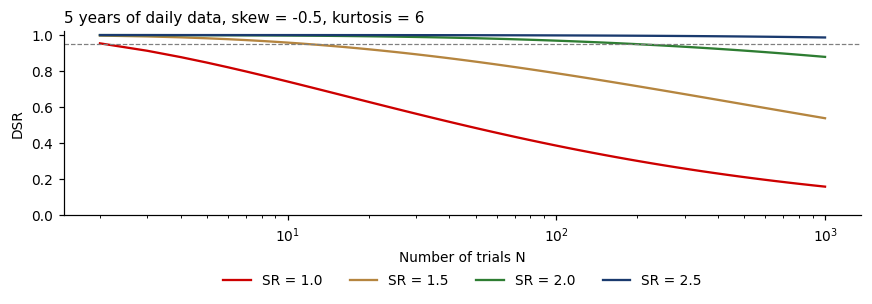

In [19]:
# apply to the walk-forward strategy from Section 10
T_s = len(strat)
sr_d = strat.mean() / strat.std()                                  # daily (per-period) SR
sk, ku = stats.skew(strat), stats.kurtosis(strat, fisher=False)
print(f'SR annualised = {sr_d * np.sqrt(252):.2f}, skew = {sk:.2f}, kurtosis = {ku:.1f}, T = {T_s}')
print(f'PSR(0) = {probabilistic_sharpe_ratio(sr_d, 0, T_s, sk, ku):.3f}')
for N in [2, 5, 20, 100]:
    print(f'N = {N:>3}: DSR = {deflated_sharpe_ratio(sr_d, T_s, N, np.sqrt(1 / T_s), sk, ku):.3f}')

T = 252 * 5
Ngrid = np.unique(np.logspace(np.log10(2), 3, 60).astype(int))
fig, ax = plt.subplots(figsize=(8, 3))
for sr_ann, c in zip([1.0, 1.5, 2.0, 2.5], [IDAred, Amber, Forest, MainBlue]):
    ax.plot(Ngrid, deflated_sharpe_ratio(sr_ann / np.sqrt(252), T, Ngrid, np.sqrt(1 / T), -0.5, 6.0),
            color=c, label=f'SR = {sr_ann}')
ax.axhline(0.95, color=Gray, ls='--', lw=0.8); ax.set_xscale('log'); ax.set_ylim(0, 1.02)
ax.set_xlabel('Number of trials N'); ax.set_ylabel('DSR'); legend_bottom(ax, ncol=4)
ax.set_title('5 years of daily data, skew = -0.5, kurtosis = 6', loc='left')
plt.tight_layout(); plt.show()

## Takeaways

1. In finance the signal-to-noise ratio is tiny: model **validation** matters more than model **choice**.
2. An ADF rejection is not stationarity: truncated FFD of an $I(1)$ price stays $I(1)$; estimate memory with local Whittle. Label outcomes the way a trader would (triple barrier).
3. Overlapping labels require **purged** cross-validation with an embargo; shuffled K-Fold can manufacture signal from noise.
4. Compare with the right benchmark ("always up", buy-and-hold) and include transaction costs.
5. Record **every** trial: the best backtest out of $N$ must be deflated (DSR) before it is believed.

**Further study (Quantinar):** [Random Forests](https://quantinar.com/course/68/RF) ·
[Shapley Values](https://quantinar.com/course/48/shapley) ·
[Machine learning in Financial Risk](https://quantinar.com/course/934/machine-learning-in-financial-risk) ·
[Introduction to Reinforcement Learning](https://quantinar.com/course/36/ReinforcementLearning)